<a href="https://colab.research.google.com/github/Keval-Trivedi299/SustainAI-Intelligent-Sustainability-Analytics-Platform/blob/main/Sustainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DATA CLEANING**

1. Import Libraries & Load Data

In [93]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/Sustainability_Project/global_urbanization_climate_metrics.csv")

2. Basic Inspection

In [94]:
print(df.shape)

(17024, 16)


In [95]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17024 entries, 0 to 17023
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   17024 non-null  object 
 1   country_code              17024 non-null  object 
 2   year                      17024 non-null  int64  
 3   total_pop                 16930 non-null  float64
 4   pop_dens_sq_km            15076 non-null  float64
 5   gdp                       14307 non-null  float64
 6   urban_pop_perc            16832 non-null  float64
 7   rural_pop_perc            16832 non-null  float64
 8   elect_access_pop          7611 non-null   float64
 9   internet_use_pop          8320 non-null   float64
 10  basic_sanitation_pop      5890 non-null   float64
 11  safe_sanitation_pop       4106 non-null   float64
 12  energy_kg_oil_eq_cap      7970 non-null   float64
 13  ren_energy_cons_perc      8234 non-null   float64
 14  clean_

In [96]:
print(df.isnull().sum())

country                         0
country_code                    0
year                            0
total_pop                      94
pop_dens_sq_km               1948
gdp                          2717
urban_pop_perc                192
rural_pop_perc                192
elect_access_pop             9413
internet_use_pop             8704
basic_sanitation_pop        11134
safe_sanitation_pop         12918
energy_kg_oil_eq_cap         9054
ren_energy_cons_perc         8790
clean_fuel_tech_cook_pop    11573
co2_emiss_excl_lulucf        3741
dtype: int64


DATA CLEANING

In [97]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [98]:
# Convert year to int
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['year'] = df['year'].fillna(df['year'].median()).astype(int)

In [99]:
# Handle missing values (IMPORTANT)
df.fillna(df.mean(numeric_only=True), inplace=True)

In [100]:
print("\nAfter Cleaning Missing Values:")
print(df.isnull().sum())


After Cleaning Missing Values:
country                     0
country_code                0
year                        0
total_pop                   0
pop_dens_sq_km              0
gdp                         0
urban_pop_perc              0
rural_pop_perc              0
elect_access_pop            0
internet_use_pop            0
basic_sanitation_pop        0
safe_sanitation_pop         0
energy_kg_oil_eq_cap        0
ren_energy_cons_perc        0
clean_fuel_tech_cook_pop    0
co2_emiss_excl_lulucf       0
dtype: int64


In [101]:
# Save Cleaned CSV
df.to_csv("cleaned_global_urbanization_climate_metrics.csv", index=False)

**EDA (Exploratory Data Analysis)**

1. Import Libraries

In [102]:
import matplotlib.pyplot as plt
import pandas as pd

2. CO₂ Emissions Trend Over Time

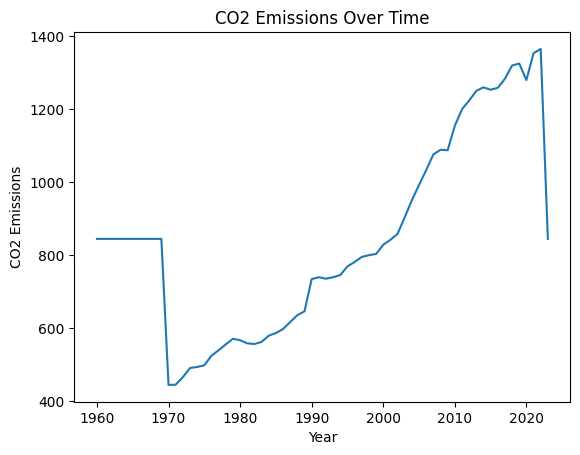

In [103]:
co2_trend = df.groupby("year")["co2_emiss_excl_lulucf"].mean()

plt.figure()
plt.plot(co2_trend)
plt.title("CO2 Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions")
plt.show()

3. Renewable Energy Usage Trend

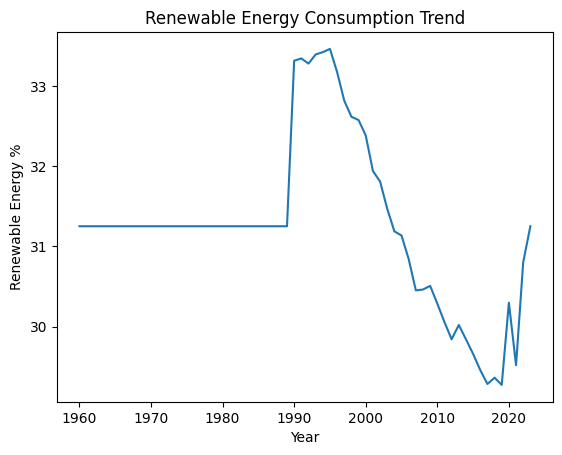

In [104]:
renew_trend = df.groupby("year")["ren_energy_cons_perc"].mean()

plt.figure()
plt.plot(renew_trend)
plt.title("Renewable Energy Consumption Trend")
plt.xlabel("Year")
plt.ylabel("Renewable Energy %")
plt.show()

4. GDP vs CO₂ Emissions

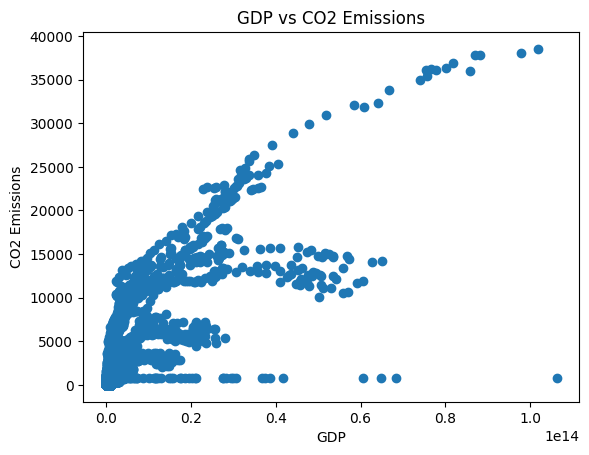

In [105]:
plt.figure()
plt.scatter(df["gdp"], df["co2_emiss_excl_lulucf"])
plt.title("GDP vs CO2 Emissions")
plt.xlabel("GDP")
plt.ylabel("CO2 Emissions")
plt.show()

5. Urban Population vs CO₂ Emissions

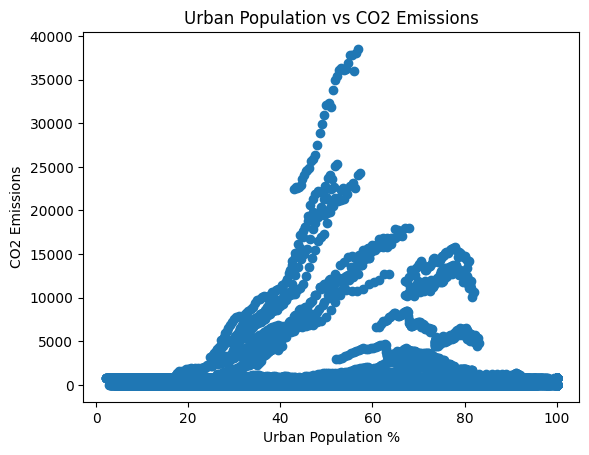

In [106]:
plt.figure()
plt.scatter(df["urban_pop_perc"], df["co2_emiss_excl_lulucf"])
plt.title("Urban Population vs CO2 Emissions")
plt.xlabel("Urban Population %")
plt.ylabel("CO2 Emissions")
plt.show()

6. Top 10 Countries by CO₂ Emissions

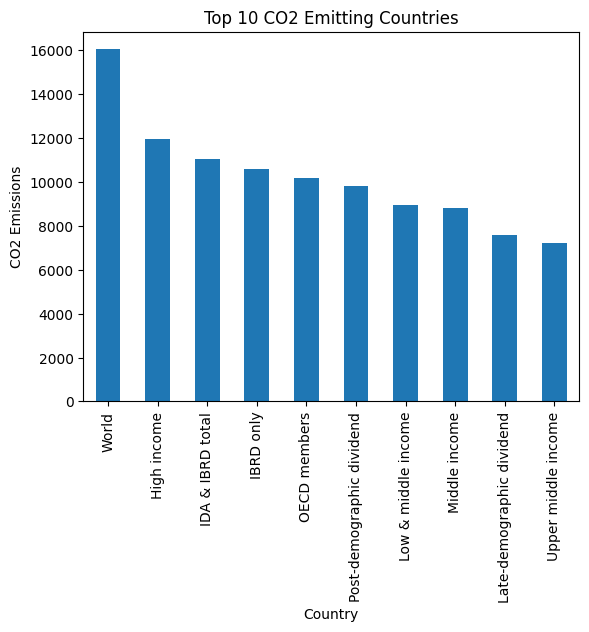

In [107]:
top_countries = df.groupby("country")["co2_emiss_excl_lulucf"].mean().sort_values(ascending=False).head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.title("Top 10 CO2 Emitting Countries")
plt.xlabel("Country")
plt.ylabel("CO2 Emissions")
plt.show()

In [108]:
print(top_countries)

country
World                        16039.225405
High income                  11960.192359
IDA & IBRD total             11035.626742
IBRD only                    10572.453176
OECD members                 10198.292215
Post-demographic dividend     9831.010395
Low & middle income           8963.592878
Middle income                 8823.113994
Late-demographic dividend     7594.474894
Upper middle income           7224.533239
Name: co2_emiss_excl_lulucf, dtype: float64


7. Renewable vs Non-Renewable (Distribution)

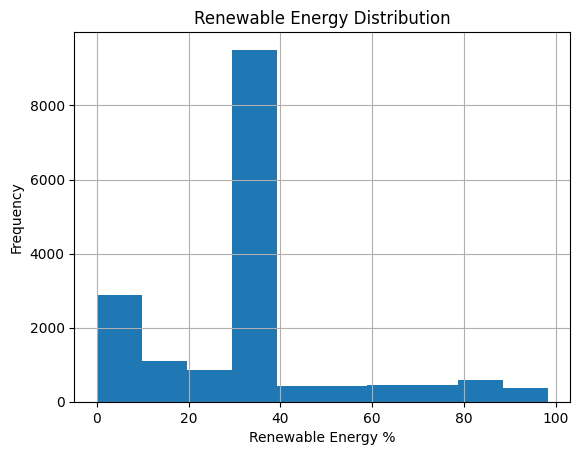

In [109]:
plt.figure()
df["ren_energy_cons_perc"].hist()
plt.title("Renewable Energy Distribution")
plt.xlabel("Renewable Energy %")
plt.ylabel("Frequency")
plt.show()

8. Correlation Heatmap (Important)

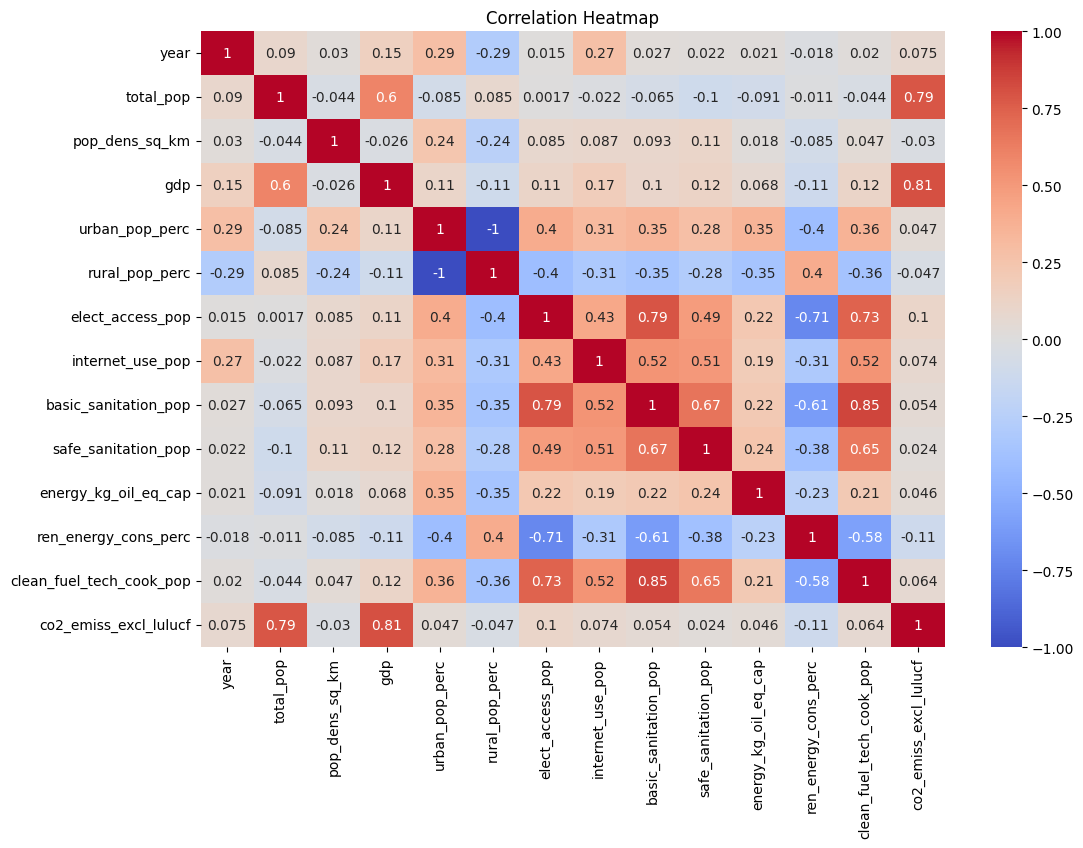

In [110]:
import seaborn as sns

plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])  # important fix
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

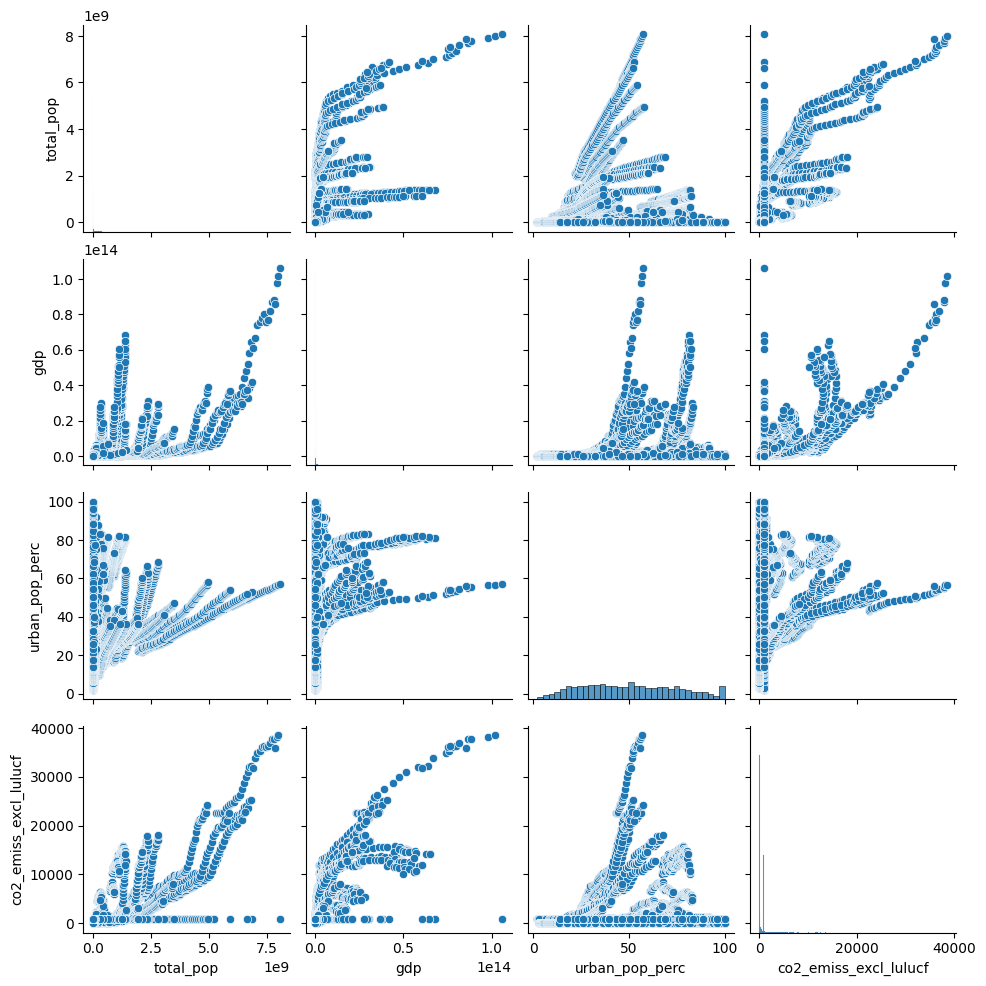

In [111]:
sns.pairplot(df, vars=['total_pop', 'gdp', 'urban_pop_perc', 'co2_emiss_excl_lulucf'])
plt.show()

FEATURE ENGINEERING

In [112]:
df['energy_efficiency'] = df['gdp'] / (df['energy_kg_oil_eq_cap'] + 1)

df['sustainability_score'] = (
    df['ren_energy_cons_perc'] * 0.4 +
    df['energy_efficiency'] * 0.3 -
    df['co2_emiss_excl_lulucf'] * 0.3
)

In [113]:
df['sustainability_label'] = pd.qcut(df['sustainability_score'], 3, labels=["Low", "Medium", "High"])

**MACHINE LEARNING MODELS**

1. Import Libraries

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

2. Select Features & Target

In [115]:
features = [
    'gdp',
    'total_pop',
    'urban_pop_perc',
    'energy_kg_oil_eq_cap',
    'ren_energy_cons_perc'
]

X = df[features]
y = df['co2_emiss_excl_lulucf']

3. Train-Test Split

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

4. Model 1: Linear Regression

In [117]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression:
RMSE: 1200.2926341146174
MAE: 531.1596031602447
R2 Score: 0.8034139518847427


5. Model 2: Random Forest (Better)

In [118]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest:
RMSE: 640.8362873736521
MAE: 121.9359101008732
R2 Score: 0.9439632935399422


6. Feature Importance (Very Important for Viva)

<Axes: >

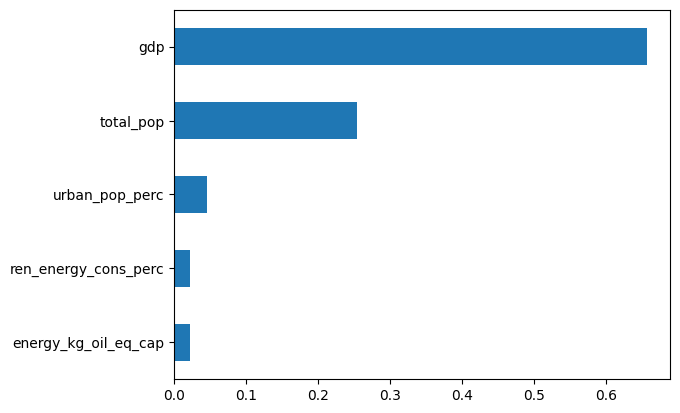

In [119]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')

Optional: Classification Model (Extra Marks)

Create Sustainability Category

In [120]:
df['sustainability_label'] = df['sustainability_score'].apply(
    lambda x: 1 if x > df['sustainability_score'].median() else 0
)

Train Classifier

In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df[features]
y = df['sustainability_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred)*100)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 99.61820851688692

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1688
           1       1.00      1.00      1.00      1717

    accuracy                           1.00      3405
   macro avg       1.00      1.00      1.00      3405
weighted avg       1.00      1.00      1.00      3405


Confusion Matrix:
 [[1680    8]
 [   5 1712]]


**Optimization & Data-Driven Insights**

1. Countries Wasting Energy (High Energy, High CO₂)

In [122]:
# High energy consumption + high emissions
energy_waste = df.groupby("country")[[
    "energy_kg_oil_eq_cap",
    "co2_emiss_excl_lulucf"
]].mean()

# Sort by both factors
energy_waste = energy_waste.sort_values(
    by=["energy_kg_oil_eq_cap", "co2_emiss_excl_lulucf"],
    ascending=False
)

print("Countries Wasting Energy:\n")
print(energy_waste.head(10))

Countries Wasting Energy:

                      energy_kg_oil_eq_cap  co2_emiss_excl_lulucf
country                                                          
Curacao                       13244.971837             844.640599
Qatar                         11211.369985             180.297070
Luxembourg                     8384.994510             154.566439
Iceland                        7722.248233             147.489223
Bahrain                        7607.291436             160.151495
United States                  6764.905537            4388.598323
North America                  6749.805391            4799.649033
United Arab Emirates           6602.872153             229.192606
Canada                         6594.017052             556.051267
Kuwait                         6418.900822             193.274497


2. Efficient vs Inefficient Countries

*   Create Efficiency Metric



In [123]:
df["energy_efficiency"] = df["gdp"] / df["energy_kg_oil_eq_cap"]


*   Most Efficient Countries



In [124]:
efficient = df.groupby("country")["energy_efficiency"].mean().sort_values(ascending=False)

print("Most Efficient Countries:\n")
print(efficient.head(10))

Most Efficient Countries:

country
World                        1.823834e+10
IDA & IBRD total             7.502866e+09
OECD members                 7.168945e+09
High income                  7.054626e+09
Low & middle income          7.041255e+09
Middle income                6.772661e+09
Post-demographic dividend    6.348943e+09
IBRD only                    6.316296e+09
East Asia & Pacific          5.306610e+09
Upper middle income          4.180016e+09
Name: energy_efficiency, dtype: float64




*   Least Efficient Countries




In [125]:
inefficient = df.groupby("country")["energy_efficiency"].mean().sort_values()

print("Least Efficient Countries:\n")
print(inefficient.head(10))

Least Efficient Countries:

country
St. Kitts and Nevis               1.801472e+05
St. Vincent and the Grenadines    2.211946e+05
Seychelles                        2.754424e+05
Central African Republic          5.054347e+05
Burundi                           5.391748e+05
Liberia                           5.435140e+05
Belize                            5.502053e+05
Suriname                          9.816479e+05
Guyana                            9.889339e+05
Sierra Leone                      1.017880e+06
Name: energy_efficiency, dtype: float64


3. Renewable Energy Leaders

In [126]:
renewable_leaders = df.groupby("country")["ren_energy_cons_perc"].mean().sort_values(ascending=False)

print("Top Renewable Energy Countries:\n")
print(renewable_leaders.head(10))

Top Renewable Energy Countries:

country
Congo, Dem. Rep.            63.856847
Uganda                      63.681047
Somalia                     62.998235
Ethiopia                    62.584972
Burundi                     62.582610
Central African Republic    62.540422
Liberia                     61.532610
Guinea-Bissau               60.634172
Bhutan                      60.570110
Tanzania                    60.139660
Name: ren_energy_cons_perc, dtype: float64


4. Visualization: Energy vs CO₂

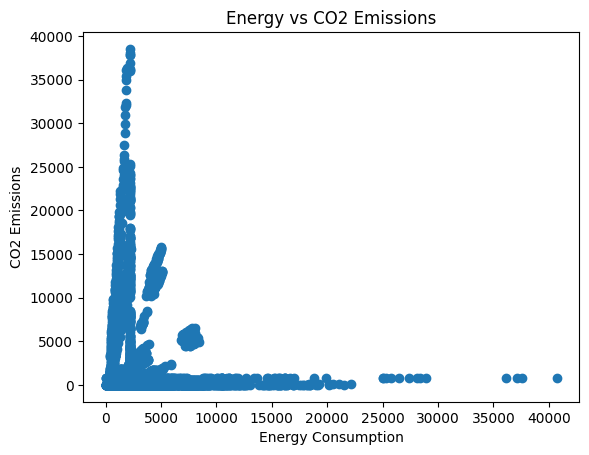

In [127]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["energy_kg_oil_eq_cap"], df["co2_emiss_excl_lulucf"])

plt.xlabel("Energy Consumption")
plt.ylabel("CO2 Emissions")
plt.title("Energy vs CO2 Emissions")

plt.show()

5. Identify High-Risk Countries (Important)

In [128]:
risk = df.groupby("country")[[
    "co2_emiss_excl_lulucf",
    "ren_energy_cons_perc"
]].mean()

# High CO2 & Low Renewable
risk = risk.sort_values(
    by=["co2_emiss_excl_lulucf", "ren_energy_cons_perc"],
    ascending=[False, True]
)

print("High Risk Countries:\n")
print(risk.head(10))

High Risk Countries:

                           co2_emiss_excl_lulucf  ren_energy_cons_perc
country                                                               
World                               16039.225405             24.510968
High income                         11960.192359             20.126721
IDA & IBRD total                    11035.626742             28.392322
IBRD only                           10572.453176             25.710559
OECD members                        10198.292215             20.729700
Post-demographic dividend            9831.010395             20.430730
Low & middle income                  8963.592878             30.225738
Middle income                        8823.113994             29.420167
Late-demographic dividend            7594.474894             24.642582
Upper middle income                  7224.533239             25.801821


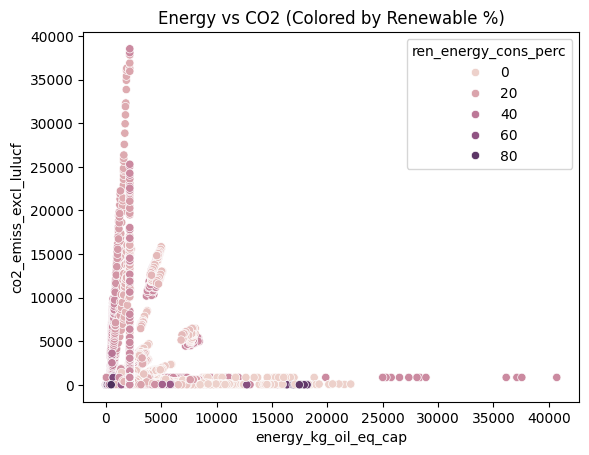

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.scatterplot(
    x="energy_kg_oil_eq_cap",
    y="co2_emiss_excl_lulucf",
    hue="ren_energy_cons_perc",
    data=df
)

plt.title("Energy vs CO2 (Colored by Renewable %)")
plt.show()

Smart Recommendation Code

In [130]:
def suggest_policy(row):
    if row["co2_emiss_excl_lulucf"] > 1000 and row["ren_energy_cons_perc"] < 20:
        return "Increase Renewable Energy"
    elif row["energy_kg_oil_eq_cap"] > 2000:
        return "Improve Energy Efficiency"
    else:
        return "Sustainable"

df["suggestion"] = df.apply(suggest_policy, axis=1)
print("Smart Recommendation")
print(df[["country", "suggestion"]].head(20))

Smart Recommendation
                        country                 suggestion
0                         Aruba  Improve Energy Efficiency
1   Africa Eastern and Southern  Improve Energy Efficiency
2                   Afghanistan  Improve Energy Efficiency
3    Africa Western and Central  Improve Energy Efficiency
4                        Angola  Improve Energy Efficiency
5                       Albania  Improve Energy Efficiency
6                       Andorra  Improve Energy Efficiency
7                    Arab World  Improve Energy Efficiency
8          United Arab Emirates  Improve Energy Efficiency
9                     Argentina  Improve Energy Efficiency
10                      Armenia  Improve Energy Efficiency
11               American Samoa  Improve Energy Efficiency
12          Antigua and Barbuda  Improve Energy Efficiency
13                    Australia  Improve Energy Efficiency
14                      Austria                Sustainable
15                   Azerbaijan  Im

**AI-BASED SOLUTIONS**

Energy Demand Forecasting (Time Series)

Step 1: Prepare Data

In [131]:
energy_data = df.groupby("year")["energy_kg_oil_eq_cap"].mean().reset_index()
energy_data['year'] = pd.to_datetime(energy_data['year'], format='%Y')
energy_data.set_index("year", inplace=True)

Step 2: Apply ARIMA Model

In [132]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(energy_data, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                                SARIMAX Results                                 
Dep. Variable:     energy_kg_oil_eq_cap   No. Observations:                   64
Model:                   ARIMA(1, 1, 1)   Log Likelihood                -363.758
Date:                  Wed, 01 Apr 2026   AIC                            733.515
Time:                          07:16:56   BIC                            739.945
Sample:                      01-01-1960   HQIC                           736.044
                           - 01-01-2023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7850      0.276      2.847      0.004       0.245       1.325
ma.L1         -0.9996      8.165     -0.122      0.903     -17.002      15.003
sigma2      5863.9960   4.69e+04    

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


Improving model: ARIMA(2,1,2)

In [133]:
from statsmodels.tsa.arima.model import ARIMA

model_2 = ARIMA(energy_data, order=(2,1,2))
model_fit_2 = model_2.fit()

print(model_fit_2.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                 
Dep. Variable:     energy_kg_oil_eq_cap   No. Observations:                   64
Model:                   ARIMA(2, 1, 2)   Log Likelihood                -363.309
Date:                  Wed, 01 Apr 2026   AIC                            736.619
Time:                          07:16:56   BIC                            747.335
Sample:                      01-01-1960   HQIC                           740.833
                           - 01-01-2023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1641      0.326     -0.504      0.614      -0.803       0.474
ar.L2          0.7333      0.335      2.188      0.029       0.076       1.390
ma.L1          0.0049      6.596    

Improving model: ARIMA(3,1,1)

In [134]:
from statsmodels.tsa.arima.model import ARIMA

model_3 = ARIMA(energy_data, order=(3,1,1))
model_fit_3 = model_3.fit()

print(model_fit_3.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                 
Dep. Variable:     energy_kg_oil_eq_cap   No. Observations:                   64
Model:                   ARIMA(3, 1, 1)   Log Likelihood                -363.148
Date:                  Wed, 01 Apr 2026   AIC                            736.296
Time:                          07:16:56   BIC                            747.011
Sample:                      01-01-1960   HQIC                           740.510
                           - 01-01-2023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6938      0.240      2.889      0.004       0.223       1.164
ar.L2          0.0560      0.276      0.203      0.839      -0.485       0.598
ar.L3          0.0804      0.281    

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Improving model: ARIMA(1,1,2)

Compare AIC:

Lower AIC = Better model

In [135]:
from statsmodels.tsa.arima.model import ARIMA

model_4 = ARIMA(energy_data, order=(1,1,2))
model_fit_4 = model_4.fit()

print(model_fit_4.summary())

                                SARIMAX Results                                 
Dep. Variable:     energy_kg_oil_eq_cap   No. Observations:                   64
Model:                   ARIMA(1, 1, 2)   Log Likelihood                -364.443
Date:                  Wed, 01 Apr 2026   AIC                            736.885
Time:                          07:16:56   BIC                            745.458
Sample:                      01-01-1960   HQIC                           740.257
                           - 01-01-2023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1511      3.681     -0.041      0.967      -7.365       7.063
ma.L1         -0.0863      3.744     -0.023      0.982      -7.424       7.251
ma.L2         -0.1444      0.915    

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


Step 3: Forecast Future Values

In [136]:
forecast = model_fit.forecast(steps=10)

print("Future Energy Demand:\n", forecast)

Future Energy Demand:
 2024-01-01    2171.211979
2025-01-01    2171.286370
2026-01-01    2171.344769
2027-01-01    2171.390614
2028-01-01    2171.426603
2029-01-01    2171.454855
2030-01-01    2171.477033
2031-01-01    2171.494444
2032-01-01    2171.508112
2033-01-01    2171.518841
Freq: YS-JAN, Name: predicted_mean, dtype: float64


Step 4: Plot Forecast

/tmp/ipykernel_9032/2090062394.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_dates = pd.date_range(


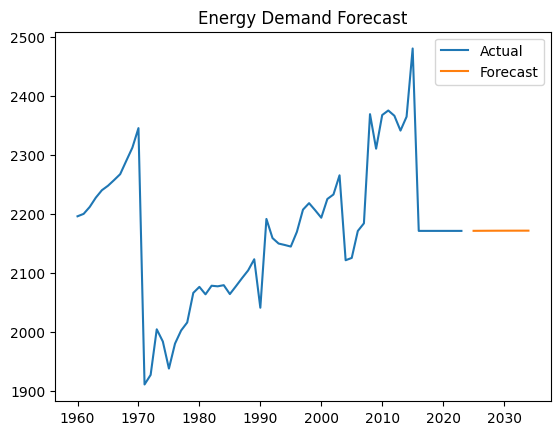

In [137]:
# Forecast (example: 10 steps)
forecast = model_fit.forecast(steps=10)

# Create future dates
future_dates = pd.date_range(
    start=energy_data.index[-1],
    periods=11,
    freq='Y'   # yearly data
)[1:]  # skip first (current year)

# Plot
plt.figure()
plt.plot(energy_data, label="Actual")
plt.plot(future_dates, forecast, label="Forecast")

plt.legend()
plt.title("Energy Demand Forecast")
plt.show()